1. Lire les fichiers .csv (données des capteurs), conversion dans la bonne unité et transformer en AC
2. Récuperer les annotations
3. Associer annotations fichier excel et valeurs des fichiers .csv (fait dans 1. et 2.)
4. Entrainement de Random Forest : (split en train et test, application de RF au train puis au test)
5. Analyser des résultats (matrices de confusion, accuracy score)

Plusieurs tests ont été effectués pour pallier le déséquilibre des classes 'mouvement' et 'non mouvement':
- équilibrage des données (séléction d'une partie (aléatoire) des données de la classe majoritaire),
- utilisation de BaggingClassifier à la place de random forest classique
- utilisation de BalancedRandomForestClassifier

In [42]:
import os
import struct
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans, DBSCAN
from agcounts_filter import convert_AC
from datetime import datetime
from scipy.stats import mode
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold, RepeatedStratifiedKFold
from sklearn.metrics import f1_score
from sklearn.ensemble import BaggingClassifier
from joblib import dump, load
from imblearn.ensemble import BalancedRandomForestClassifier

1-3 Récupération et association de X et Y 

In [ ]:
temps_depart = datetime.now()

folder_path = "C:/Users/roman/Documents/BEaCHILD/X_et_Y" 
folder = os.listdir(folder_path)

#////////////////////////////// Attention : le fichier LW est défini comme le dominant ////////////////////////////////


# Initialisation des listes contenant les données des capteurs
X_non_dom = []
X_dom = []
idx_X_non_dom = 0
idx_X_dom = 0
idx_Y_dom = 0
idx_Y_non_dom = 0

# Initialisation des listes contenant les annotations vidéos
Y_non_dom = [] 
Y_dom = []


#Parcourir les fichiers CSV
for file in folder[13:16]: # //////////////////////// Ajuster les indices pour choisir le fichier à analyser
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    # Pour les cas ou il y a des annotations avant le start
    allow_start_dom = None
    allow_start_non_dom = None

    """********************************************************************** 1. Lecture des fichiers csv ******************************************************************************"""
    if extension == ".csv":

        # Visualisation des données des capteurs
        data_file = pd.read_csv(folder_path + "/" + file, header = 5, names = ["Timestamp","Gyro X","Gyro Y","Gyro Z","Accelerometer X","Accelerometer Y","Accelerometer Z","Event","Quat W","Quat X","Quat Y","Quat Z","None"])    

        # Conversion en AC 
        dom_AC = convert_AC(folder_path + "/" + file)

        # Enregistrement des données des capteurs dans les listes qui seront donnnées au classificateur
        if file[-11:-4] == "non_dom":
            list_dom_AC = dom_AC["AC"].tolist() # Conversion du type pd.serie en type list
            for ac in list_dom_AC :
                X_non_dom.append(ac)

        elif file[-7:-4] == "dom":
            list_dom_AC = dom_AC["AC"].tolist()
            for ac in list_dom_AC:
                X_dom.append(ac)

    """********************************************************** 2. Enregistrer les annotations ***************************************************************************"""

    if extension == ".xlsx":

        my_wb = openpyxl.load_workbook(folder_path + "/" + file) 
        my_sheet = my_wb.active

        # Initialisation des décalages : sert pour éviter le décalage du aux arrondis des annotations 
        decalage_dom = 0
        decalage_non_dom = 0

        for label in my_sheet["H"]: 

            """*********************************************** Récupération du début de Y ****************************************************"""
            # dom
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_LW" :
                #start_dom = int(round(float(my_sheet.cell(label.row,13).value)))
                previous_row_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_dom = True

            # non_dom 
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_RW" :
                #start_non_dom = int(round(float(my_sheet.cell(label.row,13).value)))
                previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_non_dom = True

            """****************************************************** Récupération du contenu de Y ****************************************"""

            if label.value[0:2] == "LW" and allow_start_dom:

                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_dom.append(None) 
                    
                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value))) 
                for nb_sec in range(nb_repetitions): 
                    if X_dom and (len(Y_dom) == len(X_dom)) :
                        break
                    if label.value[3:13] == "sédentaire" :
                        Y_dom.append("non mouvement")
                    elif label.value[-2:] == "GA" or label.value[-2:] == "FA":
                        Y_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_dom.append(None) 

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_dom = label.row


            elif label.value[0:2] == "RW" and allow_start_non_dom:
                
                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_non_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_non_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_non_dom.append(None) #.append("décalage annotations")

                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value)))
                for nb_sec in range(nb_repetitions): 
                    if X_non_dom and (len(Y_non_dom) == len(X_non_dom)): 
                        break
                    if label.value[3:13] == "sédentaire" :
                        Y_non_dom.append("non mouvement")
                    elif label.value[-2:] == "GA" or label.value[-2:] == "FA":
                        Y_non_dom.append("mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_non_dom.append(None)

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_non_dom = label.row

        # CROPER X A LA LONGUEUR DE Y 
        X_dom = X_dom[:len(Y_dom)] 
        X_non_dom = X_non_dom[:len(Y_non_dom)]
        Y_dom = Y_dom[:len(X_dom)]
        Y_non_dom = Y_non_dom[:len(X_non_dom)]

print(len(X_dom))

On est dans le fichier : Data_3_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_3_non_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_3_X.xlsx
2818


Tests : Affichage des données (vérification de la synchonisation des valeurs et des annotations)

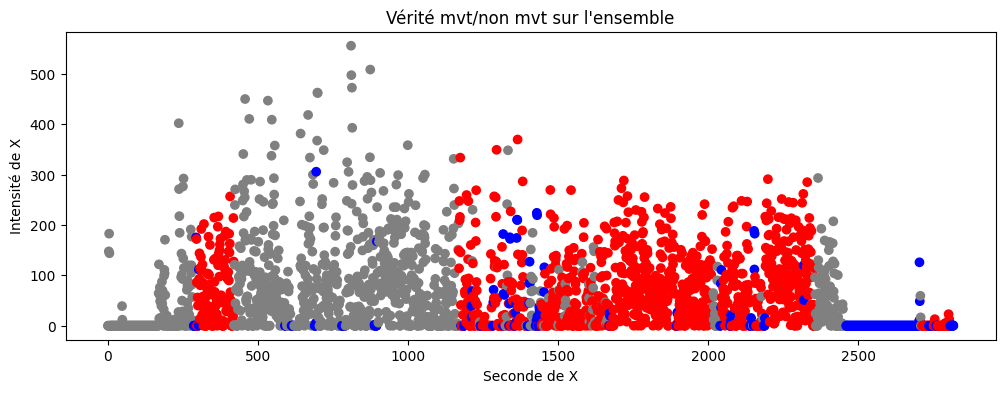

In [ ]:
# Créer des couleurs différenciant mvt/ non mvt 
# Créer un mapping couleur
color_map = {'mouvement': 'red', 'non mouvement': 'blue', None : 'grey'}
# Convertir les labels en couleurs
colors = [color_map[label] for label in Y_dom]

plt.figure(figsize=(12, 4))
plt.scatter(range(len(X_dom)), X_dom, c=colors) 
plt.title("Vérité mvt/non mvt sur l'ensemble")
plt.xlabel("Seconde de X")
plt.ylabel("Intensité de X")
plt.show()

Nettoyage et équilibrage des données

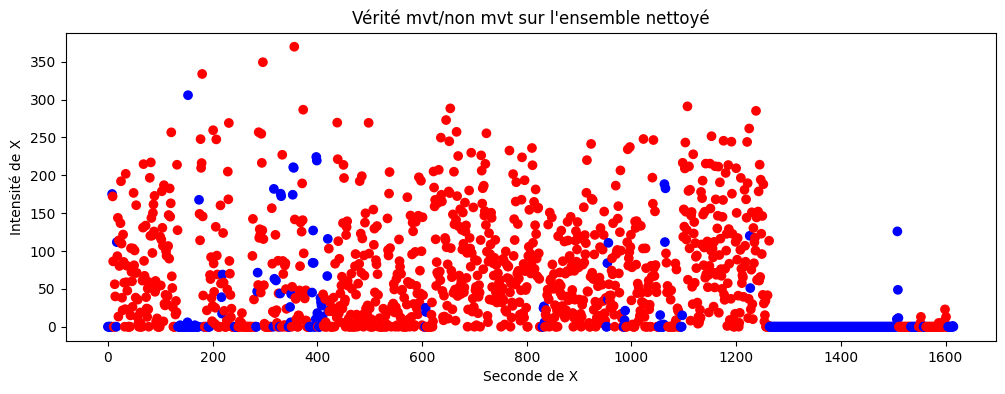

Nombre de données annotées passées à l'algorithme
len Y_flat : 862
len X_flat : 862


In [ ]:
#*************************************** Préparation des données (équilibre et suppression des None) *****************************************************************

# Convertir en array pour faciliter le filtrage
X_array = np.array(X_dom)
Y_array = np.array(Y_dom)
# Créer un masque pour garder uniquement les labels valides (différents de None)
mask_None = Y_array != None
# Appliquer le masque
X_clean = X_array[mask_None]
Y_clean = Y_array[mask_None]

# Créer des couleurs différenciant mvt/ non mvt 
# Créer un mapping couleur
color_map = {'mouvement': 'red', 'non mouvement': 'blue'}
# Convertir les labels en couleurs
colors = [color_map[label] for label in Y_clean]

plt.figure(figsize=(12, 4))
plt.scatter(range(len(X_clean)), X_clean, c=colors)
plt.title("Vérité mvt/non mvt sur l'ensemble nettoyé")
plt.xlabel("Seconde de X")
plt.ylabel("Intensité de X")
plt.show()

#Equilibrer les données : autant de mouvement que de non mouvement, et dans le meme ordre que X_array et Y_array
# Compter les "non mouvement"
n_non_mvt = np.sum(Y_clean == 'non mouvement')
n_mvt = np.sum(Y_clean == 'mouvement')
# Sélectionner les indices dans l’ordre original
indices_mvt = np.where(Y_clean == 'mouvement')[0]
indices_non_mvt = np.where(Y_clean == 'non mouvement')[0]

# Si plus de mouvement
if n_non_mvt <= n_mvt:
    # Tirage aléatoire sans remplacement
    indices_mvt_crop = np.random.choice(indices_mvt, size=n_non_mvt, replace=False)
    # Fusionner les indices en gardant l’ordre du tableau initial
    indices_final = sorted(np.concatenate((indices_non_mvt, indices_mvt_crop)))
# Si plus de non mouvement
elif n_mvt < n_non_mvt :
    # Tirage aléatoire sans remplacement
    indices_non_mvt_crop = np.random.choice(indices_non_mvt, size=n_mvt, replace=False)
    # Fusionner les indices en gardant l’ordre du tableau initial
    indices_final = sorted(np.concatenate((indices_mvt, indices_non_mvt_crop)))

# Réorganise X et Y
X_balanced = X_clean[indices_final]
Y_balanced = Y_clean[indices_final]

# Aplatir les données (mettre au bon format pour les modèles)
X_flat = np.vstack(X_balanced) 
Y_flat = np.hstack(Y_balanced)  

print("Nombre de données annotées passées à l'algorithme")
print(f'len Y_flat : {len(Y_flat)}')
print(f'len X_flat : {len(X_flat)}')



4-5 Création des modèles et analyses des résultats

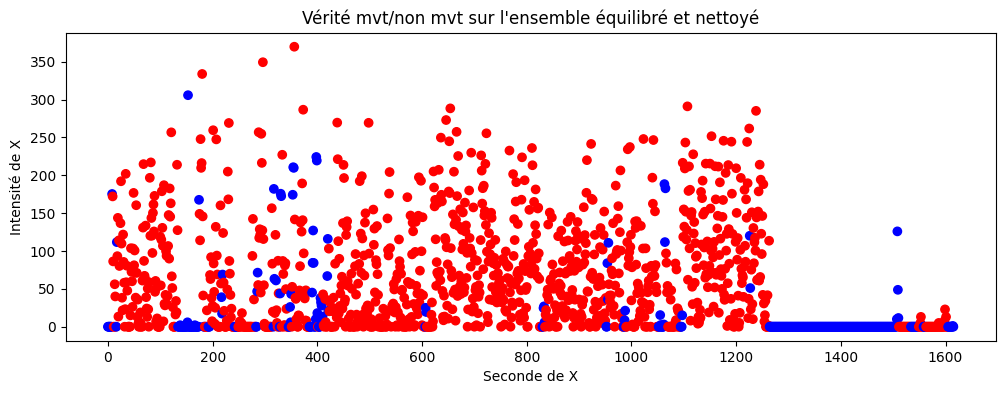

1616
1616
best model : BalancedRandomForestClassifier(max_depth=1, n_estimators=1, random_state=0)
score moyen du modèle : 0.7754271299162939
F1 score mouvement :  0.7944015415940985
Accuracy pour clustering : 0.78


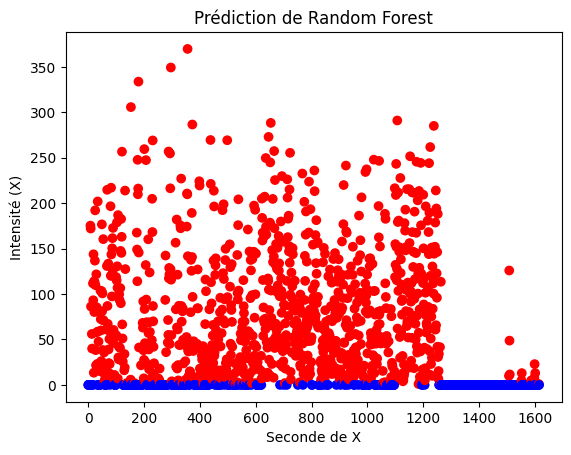

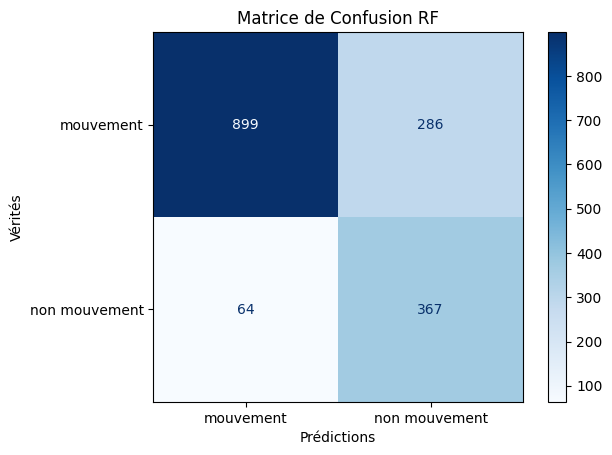

In [ ]:
#************************************** Affichage de la vérité mvt / non mvt avec les données propres ****************************************************************
# Créer des couleurs différenciant mvt/ non mvt 
# Créer un mapping couleur
color_map = {'mouvement': 'red', 'non mouvement': 'blue'}
# Convertir les labels en couleurs
colors = [color_map[label] for label in Y_clean]

plt.figure(figsize=(12, 4))
plt.scatter(range(len(X_clean)), X_clean, c=colors) # plt.scatter(range(len(X_flat[0:500])), X_flat[0:500], c=clusters[0:500], cmap='viridis')
plt.title("Vérité mvt/non mvt sur l'ensemble équilibré et nettoyé")
plt.xlabel("Seconde de X")
plt.ylabel("Intensité de X")
plt.show()


#*************************************** Random Forest *****************************************************************
# Split data into train and test samples
#X_train, X_test, y_train, y_test = train_test_split(X_flat, Y_flat, test_size=0.2)
# Only for simple training, not kfold training
"""

# ***************************************************** Grid search ******************************************************
# A ne faire tourner qu'une seule fois pour trouver les hyperparamètres otpimaux
param_grid = {
    'n_estimators': [1, 10, 50, 100, 200],
    'max_depth': [None,1, 5, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}
grid_search = GridSearchCV(Random_Forest, param_grid, cv=5)
grid_search.fit(X_flat, y_flat)
best_model = grid_search.best_estimator_
scores = cross_val_score(grid_search, X_flat, Y_flat, cv=5)
# Final evaluation on untouched test set
#test_score = best_model.score(X_test, y_test)
print(f"Score sur le jeu de test : {test_score:.4f}")
print(f"best model : {best_model}")
print(f"score moyen du modèle : {scores.mean()}")
#***************************************************************************************************************************

"""
# Initialize the model
# max_depth=5, min_samples_split=5, n_estimators=200, pour data5
 #Random_Forest = RandomForestClassifier(random_state=42,max_depth = 1, n_estimators=10) #max_depth = 5, n_estimators=10) # Paramètres déterminés par Gridsearch et ceux là sont les meilleurs pour tous les fichiers, en non_dom 

"""# Kfold definition
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Creating an array to register all the predictions (made on the different fold)
predictions = np.empty_like(Y_flat)

for train_idx, test_idx in kf.split(X_flat):
    # Train the model
    Random_Forest.fit(X_flat[train_idx], Y_flat[train_idx])
    # Test the model
    y_pred = Random_Forest.predict(X_flat[test_idx])
    predictions[test_idx] = y_pred"""


""" #--------------------------- Déséquilibre essai 1 : Bagging -----------------------------------------
# Bagging pour dataset déséquilibré
model = BaggingClassifier()
# Entrainement et test par fold
cv = RepeatedStratifiedKFold(n_splits = 10, n_repeats = 3, random_state = 1) # Stratified pour garder le meme déséquilibre dans chaque fold que dans l'ensemble Y_dom (ou Y_non_dom) et Repeated pour entrainer sur d'autre division de groupe (entrainement plus robuste) 
# Evaluation du modèle
scores = cross_val_score(model, X_flat, Y_flat, scoring = 'f1_macro', cv = cv, n_jobs = -1) # scoring = "f1_macro" ne tient pas compte du déséquilibre des classes
print("f1 score : ", np.mean(scores))
"""

#--------------------------- Déséquilibre essai 2 : Balanced Random Forest -----------------------------------------
brf = BalancedRandomForestClassifier( sampling_strategy="all", replacement=True, max_depth=2, random_state=0, bootstrap=False)
brf.fit(X_flat,Y_flat)
predictions = brf.predict(X_flat)

param_grid = {
    'n_estimators': [1, 10, 50, 100, 200],
    'max_depth': [None,1, 5, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}
grid_search = GridSearchCV(brf, param_grid, cv=5)
grid_search.fit(X_flat, Y_flat)
best_model = grid_search.best_estimator_
mean_scores = cross_val_score(grid_search, X_flat, Y_flat, cv=5)

print(f"best model : {best_model}")
print(f"score moyen du modèle : {mean_scores.mean()}")

# F1 score
f1score_weighted = f1_score(Y_flat, predictions, labels = ["non mouvement", "mouvement"], average = "weighted")
print("F1 score mouvement : ", f1score_weighted)

# Accuracy
accuracy = accuracy_score(Y_flat, predictions)
print(f"Accuracy pour clustering : {accuracy:.2f}")
cm_cluster = confusion_matrix(Y_flat, predictions)


# Evaluation of the model
#accuracy = accuracy_score(Y_flat, predictions)
#print(f"Accuracy pour RF : {accuracy:.2f}")
# Moyenne  de la précision du modèle
#scores = cross_val_score(Random_Forest, X_flat, Y_flat, cv=kf, scoring = 'accuracy')
#print(f"score d'accuracy moyen du modèle : {scores.mean()}")

# Train the model
#Random_Forest.fit(X_train, y_train)

# Save the model
#dump(Random_Forest, 'model_data_5_kfold_non_dom.joblib') # /////////////////////////// Changer le nom du modèle à enregistrer

# Test the model
#y_pred =Random_Forest.predict(X_test)

#*************************************** Affichage de la vérité mvt / non mvt avec les données propres *****************************************************************

# Créer des couleurs différenciant les prédictions mvt/ non mvt 
# Mapping
color_map = {'mouvement': 'red', 'non mouvement': 'blue'}
# Convertir les labels en couleurs
colors = [color_map[label] for label in predictions]
plt.scatter(range(len(X_flat)), X_flat, c=colors) #plt.scatter(range(len(X_test)), X_test, c=colors)
plt.title("Prédiction de Random Forest")
plt.xlabel("Seconde de X")
plt.ylabel("Intensité (X)")
plt.show()

cm_RF = confusion_matrix(Y_flat, predictions) # cm_RF = confusion_matrix(y_test, y_pred)
# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm_RF, display_labels= ["mouvement", "non mouvement"])
disp.plot(cmap="Blues")
disp.ax_.set_title("Matrice de Confusion RF")
disp.ax_.set_xlabel("Prédictions")
disp.ax_.set_ylabel("Vérités")
plt.show()


Clustering

In [ ]:
#********************************* Clustering **********************************************************************************
"""
#----------------------------------- KMEANS CLASSIQUE DONNE DE MAUVAIS RESULTATS (accuracy à 63%) ------------------------------------
k = 2  # nombre de clusters 
kmeans = KMeans(n_clusters=k)#, init = 'k-means++', n_init = 'auto', algorithm = "elkan")
clusters = kmeans.fit_predict(X_flat)
centroids = np.array(kmeans.cluster_centers_)
print(centroids)
"""
"""
#----------------------------------- GMM  DONNE DE BONS RESULTATS  (accuracy à 84%)
gmm = GaussianMixture(n_components=2, random_state=42)
clusters = gmm.fit_predict(X_flat)


# ----------------------------------- DBSCAN DONNE DE BONS RESULTATS  (accuracy à 86%)

# Appliquer DBSCAN
db = DBSCAN(eps=0.01, min_samples=1) #esp = 0.8, min samples = 20 -> accuracy de 74% avec 2 clusters # /////////////////////////// Changer les paramètres pour voir les optimaux ceux la semblent bien
clusters = db.fit_predict(X_flat) # X_dbscan)

# ON NE PEUT PAS UTILISER GRIDSEARCH SUR DES METHODES NON SUPERVISEES COMME DU CLUSTERING
"""
"""# Afficher les labels uniques
print("Labels trouvés :", np.unique(clusters)) 
# Créer un tableau pour mapper chaque cluster à la classe dominante (la classe 0 n'est pas forcément 'non_mvt' c'est pq il faut associer le chiffre au nom)
labels_map = {}
for cluster_id in np.unique(clusters):
    mask = clusters == cluster_id
    majority_class =  pd.Series(Y_flat[mask]).mode()[0]
    labels_map[cluster_id] = majority_class
# Traduire les clusters en classes
predicted_labels = np.array([labels_map[c] for c in clusters])
"""
"""
# Mapping pour cluster
labels_map = ["",""]
if centroids[1][0] > centroids[0][0]:
    labels_map[0] = 'non mouvement'
    labels_map[1] = 'mouvement'
else:
    labels_map[0] = 'mouvement'
    labels_map[1] = 'non mouvement'

# Traduire les clusters en classess
predicted_labels = [labels_map[c] for c in clusters] # np.array([labels_map[c] for c in clusters])
# Créer des couleurs différenciant mvt/ non mvt et pas différenciant les clusters
# Créer un mapping couleur
color_map = {'mouvement': 'red', 'non mouvement': 'blue'}
# Convertir les labels en couleurs
colors = [color_map[label] for label in predicted_labels]

plt.scatter(range(len(X_flat)), X_flat, c=colors)#couleurs plus jolies : cmap = "viridis" # plt.scatter(range(len(X_flat[0:500])), X_flat[0:500], c=clusters[0:500], cmap='viridis')
#plt.scatter([len(X_flat)/2 ,len(X_flat)/2], [centroids[0][0], centroids[1][0]], color='black', marker='X', s=100, label='Centroids') # Affichage des centres des clusters
plt.title("Clusters sur l'intensité")
plt.xlabel("Seconde de X")
plt.ylabel("Intensité (X)")
plt.show()

# Evaluer le modèle
accuracy = accuracy_score(Y_flat, predicted_labels)
print(f"Accuracy pour clustering : {accuracy:.2f}")
cm_cluster = confusion_matrix(Y_flat, predicted_labels)

# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cluster, display_labels= ["mouvement", "non mouvement"])
disp.plot(cmap="Blues")
disp.ax_.set_title("Matrice de Confusion Clustering")
disp.ax_.set_xlabel("Prédictions")
disp.ax_.set_ylabel("Vérités")
#disp.figure_.show()
plt.show()

"""

'\n# Mapping pour cluster\nlabels_map = ["",""]\nif centroids[1][0] > centroids[0][0]:\n    labels_map[0] = \'non mouvement\'\n    labels_map[1] = \'mouvement\'\nelse:\n    labels_map[0] = \'mouvement\'\n    labels_map[1] = \'non mouvement\'\n\n# Traduire les clusters en classess\npredicted_labels = [labels_map[c] for c in clusters] # np.array([labels_map[c] for c in clusters])\n# Créer des couleurs différenciant mvt/ non mvt et pas différenciant les clusters\n# Créer un mapping couleur\ncolor_map = {\'mouvement\': \'red\', \'non mouvement\': \'blue\'}\n# Convertir les labels en couleurs\ncolors = [color_map[label] for label in predicted_labels]\n\nplt.scatter(range(len(X_flat)), X_flat, c=colors)#couleurs plus jolies : cmap = "viridis" # plt.scatter(range(len(X_flat[0:500])), X_flat[0:500], c=clusters[0:500], cmap=\'viridis\')\n#plt.scatter([len(X_flat)/2 ,len(X_flat)/2], [centroids[0][0], centroids[1][0]], color=\'black\', marker=\'X\', s=100, label=\'Centroids\') # Affichage des cen

Test du modèle (F1 score, accuracy et matrice de confusion)

In [ ]:
"""RF_model = load('model_data_4_kfold_non_dom.joblib') # /////////////////////////// Changer le nom du modèle à lancer
# Test the model
y_pred = RF_model.predict(X_flat)

#********************************************* Evaluate the model *****************************************************************
# F1 score
f1score_mouvement = f1_score(Y_flat, y_pred, labels = ["non mouvement","mouvement"], pos_label = "mouvement")
f1score_non_mouvement = f1_score(Y_flat, y_pred, labels = ["non mouvement","mouvement"], pos_label = "non mouvement")
print("F1 score : ", f1score_non_mouvement)
print("F1 score : ", f1score_mouvement)

# Accuracy
accuracy = accuracy_score(Y_flat, y_pred)
print(f"Accuracy pour RF : {accuracy:.2f}")

#*************************************** Affichage de la vérité mvt / non mvt avec les données propres *****************************************************************
# Créer des couleurs différenciant mvt/ non mvt 
# Créer un mapping couleur
color_map = {'mouvement': 'red', 'non mouvement': 'blue'}
# Convertir les labels en couleurs
colors = [color_map[label] for label in Y_flat]

plt.scatter(range(len(X_flat)), X_flat, c=colors) 
plt.title("Vérité mvt/non mvt sur l'ensemble de test équilibré et nettoyé")
plt.xlabel("Seconde de X")
plt.ylabel("Intensité de X")
plt.show()

# Créer des couleurs différenciant les prédictions mvt/ non mvt 
# Mapping
color_map = {'mouvement': 'red', 'non mouvement': 'blue'}
# Convertir les labels en couleurs
colors = [color_map[label] for label in y_pred]
plt.scatter(range(len(X_flat)), X_flat, c=colors)
plt.title("Prédiction de Random Forest")
plt.xlabel("Seconde de X")
plt.ylabel("Intensité (X)")
plt.show()

cm_RF = confusion_matrix(Y_flat, y_pred)
# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm_RF, display_labels= ["mouvement", "non mouvement"])
disp.plot(cmap="Blues")
disp.ax_.set_title("Matrice de Confusion RF")
disp.ax_.set_xlabel("Prédictions")
disp.ax_.set_ylabel("Vérités")
#disp.figure_.show()
plt.show()


"""

'RF_model = load(\'model_data_4_kfold_non_dom.joblib\')\n# Test the model\ny_pred = RF_model.predict(X_flat)\n\n#********************************************* Evaluate the model *****************************************************************\n# F1 score\nf1score_mouvement = f1_score(Y_flat, y_pred, labels = ["non mouvement","mouvement"], pos_label = "mouvement")\nf1score_non_mouvement = f1_score(Y_flat, y_pred, labels = ["non mouvement","mouvement"], pos_label = "non mouvement")\nprint("F1 score : ", f1score_non_mouvement)\nprint("F1 score : ", f1score_mouvement)\n\n# Accuracy\naccuracy = accuracy_score(Y_flat, y_pred)\nprint(f"Accuracy pour RF : {accuracy:.2f}")\n\n#*************************************** Affichage de la vérité mvt / non mvt avec les données propres *****************************************************************\n# Créer des couleurs différenciant mvt/ non mvt \n# Créer un mapping couleur\ncolor_map = {\'mouvement\': \'red\', \'non mouvement\': \'blue\'}\n# Conver